# CSET419 — Introduction to Generative AI
## Lab 10 — Sequential Data Generation

**Objective:**  
Implement generative models capable of learning patterns from sequential data and generating new sequences.  
We explore two deep-learning architectures:
- **Component I:** RNN / LSTM Based Sequential Data Generation  
- **Component II:** Transformer Based Sequential Data Generation

---

### Learning Outcomes
After completing this lab, students will be able to:
1. Understand the concept of sequential data generation
2. Preprocess sequence datasets for deep learning models
3. Implement generative models for sequence prediction
4. Train neural network models to generate new sequences
5. Evaluate the quality and coherence of generated sequences

---
## 📦 Step 0 — Import Libraries

We use **PyTorch** as our deep-learning framework.  
All modules needed for both Component I (LSTM) and Component II (Transformer) are imported here.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Using device    : {device}')

PyTorch version : 2.10.0+cpu
Using device    : cpu


---
## 📄 Step 1 — Load & Understand the Dataset

The dataset is a **small text corpus** of 16 sentences covering AI / ML concepts.  
We treat it as a single continuous character stream (character-level language model).

**Why character-level?**  
- No external tokenizer needed.  
- Vocabulary is just the unique characters in the text.  
- The model learns spelling, grammar, and word patterns simultaneously.

In [2]:
# ---------- Raw corpus (as given in the lab sheet) ----------
corpus = [
    "artificial intelligence systems learn patterns from data",
    "sequence models process information step by step",
    "recurrent neural networks are useful for sequence prediction",
    "lstm networks handle long term dependencies",
    "deep learning models improve sequence learning",
    "generative models create new samples from learned patterns",
    "language models predict the next word in a sentence",
    "sequence generation is used in chatbots and assistants",
    "machine learning helps computers learn automatically",
    "training data improves model accuracy",
    "neural networks simulate human brain structures",
    "optimization algorithms improve learning efficiency",
    "technology is transforming modern education",
    "online learning platforms use artificial intelligence",
    "students benefit from intelligent tutoring systems",
    "automation improves productivity and decision making",
]

# Join into one long string separated by newlines
full_text = "\n".join(corpus)

print(f'Total characters : {len(full_text)}')
print(f'Total sentences  : {len(corpus)}')
print('\n--- First 200 characters of corpus ---')
print(full_text[:200])

Total characters : 816
Total sentences  : 16

--- First 200 characters of corpus ---
artificial intelligence systems learn patterns from data
sequence models process information step by step
recurrent neural networks are useful for sequence prediction
lstm networks handle long term de


---
## 🔤 Step 2 — Character-Level Tokenisation

Tokenisation converts raw text into integers that a neural network can process.

| Concept | Meaning |
|---|---|
| `vocab` | Sorted list of all unique characters |
| `char2idx` | Dict mapping each character → integer index |
| `idx2char` | Reverse dict: integer → character (used for decoding) |
| `vocab_size` | Total number of unique characters |

The model will output a probability distribution over `vocab_size` classes, and we sample the next character from that distribution.

In [3]:
# Build character vocabulary
vocab    = sorted(set(full_text))          # unique characters, sorted
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(vocab)

print(f'Vocabulary size : {vocab_size}')
print(f'Characters      : {repr("".join(vocab))}')

# Encode the full text as a list of integers
encoded = [char2idx[c] for c in full_text]

print(f'\nSample encoding of "deep": {[char2idx[c] for c in "deep"]}')
print(f'Encoded length : {len(encoded)}')

Vocabulary size : 27
Characters      : '\n abcdefghiklmnopqrstuvwxyz'

Sample encoding of "deep": [5, 6, 6, 16]
Encoded length : 816


---
## 🧩 Step 3 — Create Input-Output Sequence Pairs

We use a **sliding window** approach:
- **Input  X[i]**: characters at positions `[i … i+SEQ_LEN-1]`  
- **Target y[i]**: character at position `i+SEQ_LEN`  

The model learns: *given the last `SEQ_LEN` characters, predict the next one.*

```
SEQ_LEN = 30
Text  : a r t i f i c i a l   i n t e l l i g e n c e   s y s t e m
X[0]  : a r t i f i c i a l   i n t e l l i g e n c e   s y s t e m   ← 30 chars
y[0]  : s                                                              ← char 31
```

In [4]:
SEQ_LEN = 30   # length of each input sequence

X_list, y_list = [], []
for i in range(len(encoded) - SEQ_LEN):
    X_list.append(encoded[i : i + SEQ_LEN])
    y_list.append(encoded[i + SEQ_LEN])

X = torch.tensor(X_list, dtype=torch.long)
y = torch.tensor(y_list, dtype=torch.long)

print(f'Input tensor shape  : {X.shape}  → (num_samples, seq_len)')
print(f'Target tensor shape : {y.shape}  → (num_samples,)')

# Show one example
print('\n--- Example sequence pair ---')
print('X[0] :', ''.join([idx2char[i] for i in X[0].tolist()]))
print('y[0] :', idx2char[y[0].item()])

Input tensor shape  : torch.Size([786, 30])  → (num_samples, seq_len)
Target tensor shape : torch.Size([786])  → (num_samples,)

--- Example sequence pair ---
X[0] : artificial intelligence system
y[0] : s


---
## 🔁 Step 4 — DataLoader Setup

We wrap our tensors in a `TensorDataset` and create a `DataLoader`  
for **mini-batch training** (both components share the same data loader).

In [5]:
BATCH_SIZE = 64

dataset    = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'Total samples  : {len(dataset)}')
print(f'Batch size     : {BATCH_SIZE}')
print(f'Batches/epoch  : {len(dataloader)}')

Total samples  : 786
Batch size     : 64
Batches/epoch  : 13


---
---
# 🔷 COMPONENT I — LSTM Based Sequential Data Generation

### Architecture Overview

```
Input (seq_len integers)
        │
   Embedding Layer          ← converts each char-index to a dense vector
        │
   LSTM (2 layers)          ← remembers long-range dependencies
        │   (take only last hidden state)
   Fully Connected Layer    ← projects hidden state → vocab_size logits
        │
   Softmax (during generation) → probability of each character
```

**Why LSTM?**  
Standard RNNs suffer from the *vanishing gradient problem* — they forget information from far back in the sequence.  
LSTM adds **cell state** and **three gating mechanisms** (input, forget, output) that allow gradients to flow over long sequences.

In [6]:
class LSTMModel(nn.Module):
    """
    Character-level generative LSTM.

    Parameters
    ----------
    vocab_size  : number of unique characters
    embed_dim   : embedding dimension for each character
    hidden_dim  : number of LSTM hidden units per layer
    num_layers  : number of stacked LSTM layers
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256, num_layers=2):
        super(LSTMModel, self).__init__()

        # 1. Embedding: maps integer indices → continuous vectors
        self.embed = nn.Embedding(vocab_size, embed_dim)

        # 2. LSTM: processes the sequence of embeddings
        self.lstm  = nn.LSTM(embed_dim, hidden_dim,
                             num_layers=num_layers,
                             batch_first=True,
                             dropout=0.3)

        # 3. Fully Connected: maps final hidden state → vocab logits
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embed(x)          # → (batch, seq_len, embed_dim)
        out, _ = self.lstm(emb)      # → (batch, seq_len, hidden_dim)
        logits = self.fc(out[:, -1, :])  # take last time-step → (batch, vocab_size)
        return logits


lstm_model = LSTMModel(vocab_size).to(device)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

LSTMModel(
  (embed): Embedding(27, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=27, bias=True)
)

Total trainable parameters: 864,731


### Training the LSTM

- **Loss Function:** `CrossEntropyLoss` — standard for multi-class classification  
- **Optimizer:** Adam with `lr=0.003`  
- **Epochs:** 150 — enough for the small corpus to converge  

We print loss every 10 epochs and store all epoch losses for plotting.

In [7]:
EPOCHS_LSTM  = 150
LR_LSTM      = 0.003

criterion    = nn.CrossEntropyLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR_LSTM)

lstm_losses = []
print('Training LSTM model...')
print(f'{"Epoch":>6}  {"Loss":>10}')
print('-' * 20)

for epoch in range(1, EPOCHS_LSTM + 1):
    lstm_model.train()
    epoch_loss = 0.0

    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        lstm_optimizer.zero_grad()
        logits = lstm_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)  # gradient clipping
        lstm_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    lstm_losses.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {avg_loss:>10.4f}')

print('\nLSTM Training complete!')

Training LSTM model...
 Epoch        Loss
--------------------
     1      3.0660
    10      1.1434
    20      0.1891
    30      0.0572
    40      0.0197
    50      0.0063
    60      0.0026
    70      0.0018
    80      0.0014
    90      0.0011
   100      0.0008
   110      0.0007
   120      0.0006
   130      0.0005
   140      0.0005
   150      0.0004

LSTM Training complete!


### Visualise LSTM Training Loss

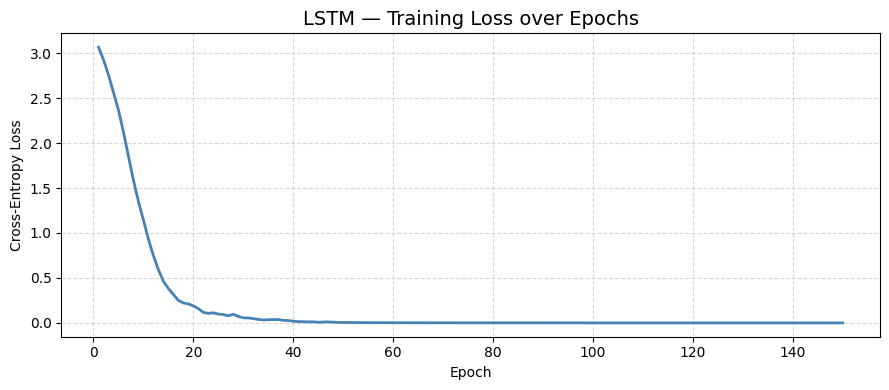

In [8]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS_LSTM + 1), lstm_losses, color='steelblue', linewidth=2)
plt.title('LSTM — Training Loss over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 🎯 Sequence Generation — LSTM

**Temperature Sampling**  
After obtaining the model's logits we divide by a `temperature` value before applying softmax:

| Temperature | Effect |
|---|---|
| `< 1.0` | Sharper distribution → more predictable / repetitive text |
| `= 1.0` | Raw model distribution |
| `> 1.0` | Flatter distribution → more diverse / surprising text |

The function accepts a **seed string**, pads it to `SEQ_LEN`, and autoregressively appends one character at a time.

In [9]:
def generate_lstm(model, seed, length=150, temperature=0.7):
    """
    Generate text using the LSTM model.

    Parameters
    ----------
    model       : trained LSTMModel
    seed        : seed string (must be <= SEQ_LEN characters)
    length      : number of characters to generate
    temperature : sampling temperature

    Returns
    -------
    str : seed + generated characters
    """
    model.eval()
    result  = seed

    # Encode seed; pad with zeros on the left if shorter than SEQ_LEN
    context = [char2idx.get(c, 0) for c in seed]
    pad_len = max(0, SEQ_LEN - len(context))
    context = [0] * pad_len + context   # left-pad

    with torch.no_grad():
        for _ in range(length):
            inp    = torch.tensor([context[-SEQ_LEN:]], dtype=torch.long).to(device)
            logits = model(inp)[0] / temperature
            probs  = torch.softmax(logits, dim=0).cpu().numpy()
            # Sample from the probability distribution
            idx    = int(np.random.choice(len(probs), p=probs))
            result += idx2char[idx]
            context.append(idx)

    return result


# ─── Generate sequences with different seeds ─────────────────────────────────
seeds = [
    "deep learning",
    "neural networks",
    "sequence generation",
    "artificial",
]

print('=' * 65)
print('  LSTM — Generated Sequences (temperature = 0.7)')
print('=' * 65)
for seed in seeds:
    generated = generate_lstm(lstm_model, seed, length=120, temperature=0.7)
    print(f'\n[Seed: "{seed}"]')
    print(generated)
    print('-' * 65)

  LSTM — Generated Sequences (temperature = 0.7)

[Seed: "deep learning"]
deep learning platforms use artificial intelligence
students benefit from intelligent tutoring systems
automation improves productivi
-----------------------------------------------------------------

[Seed: "neural networks"]
neural networks are useful for sequence prediction
lstm networks handle long term dependencies
deep learning models improve sequence le
-----------------------------------------------------------------

[Seed: "sequence generation"]
sequence generation is used in chatbots and assistants
machine learning helps computers learn automatically
training data improves model ac
-----------------------------------------------------------------

[Seed: "artificial"]
artificial intelligence
students benefit from intelligent tutoring systems
automation improves productivity and decision making he
-----------------------------------------------------------------


### Effect of Temperature on LSTM Output

In [10]:
seed = "machine learning"
print(f'Seed: "{seed}"\n')
print('=' * 65)
for temp in [0.4, 0.7, 1.0, 1.3]:
    gen = generate_lstm(lstm_model, seed, length=100, temperature=temp)
    print(f'Temperature = {temp}:')
    print(gen)
    print('-' * 65)

Seed: "machine learning"

Temperature = 0.4:
machine learning helps computers learn automatically
training data improves model accuracy
neural networks simulate 
-----------------------------------------------------------------
Temperature = 0.7:
machine learning helps computers learn automatically
training data improves model accuracy
neural networks simulate 
-----------------------------------------------------------------
Temperature = 1.0:
machine learning helps computers learn automatically
training data improves model accuracy
neural networks simulate 
-----------------------------------------------------------------
Temperature = 1.3:
machine learning helps computers learn automatically
training data improves model accuracy
neural networks simulate 
-----------------------------------------------------------------


---
---
# 🔶 COMPONENT II — Transformer Based Sequential Data Generation

### Architecture Overview

```
Input (seq_len integers)
        │
   Embedding Layer
        │
   Positional Encoding       ← injects order information (sine / cosine waves)
        │
   Transformer Encoder       ← multi-head self-attention + feed-forward layers
   (N stacked layers)
        │   (take only last token's representation)
   Fully Connected Layer     → vocab_size logits
```

### Why Positional Encoding?
Transformers process all tokens **in parallel** using self-attention — they have no built-in notion of order.  
Positional Encoding adds **position information** by injecting sinusoidal signals:

$$PE_{(pos,2i)}   = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Each position gets a unique pattern of sines and cosines, allowing the model to distinguish position 1 from position 30, etc.

In [11]:
class PositionalEncoding(nn.Module):
    """
    Adds sinusoidal positional encoding to token embeddings.

    Parameters
    ----------
    d_model : embedding dimension
    max_len : maximum sequence length supported
    """
    def __init__(self, d_model, max_len=512):
        super(PositionalEncoding, self).__init__()

        # Pre-compute a table of shape (max_len, d_model)
        pe  = torch.zeros(max_len, d_model)                              # (max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()             # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )                                                                 # (d_model/2,)

        pe[:, 0::2] = torch.sin(pos * div)   # even indices
        pe[:, 1::2] = torch.cos(pos * div)   # odd indices

        # Register as buffer (not a learnable parameter)
        self.register_buffer('pe', pe.unsqueeze(0))                     # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

### Visualise Positional Encoding

Each row is a position; each column is a dimension.  
You can see how different frequencies tile the space, giving every position a unique fingerprint.

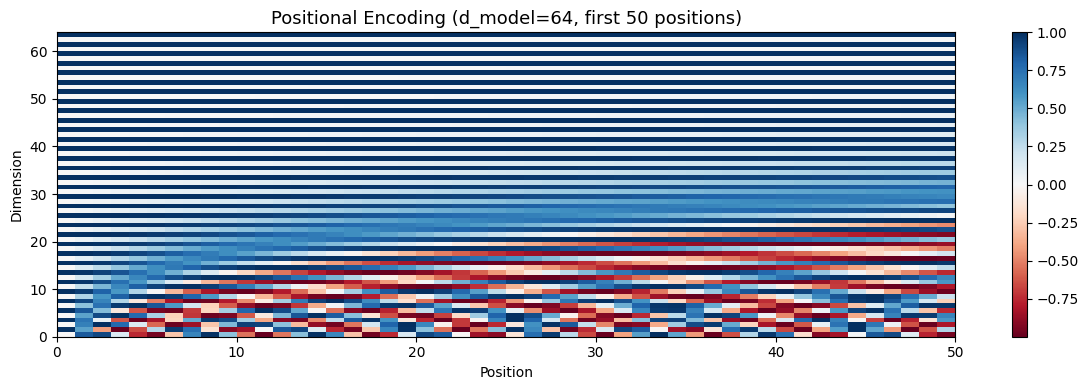

In [12]:
D_MODEL = 64   # embedding dimension used in our Transformer

# Compute PE table for visualisation
pe_vis = torch.zeros(50, D_MODEL)
pos_v  = torch.arange(0, 50).unsqueeze(1).float()
div_v  = torch.exp(torch.arange(0, D_MODEL, 2).float() * (-math.log(10000.0) / D_MODEL))
pe_vis[:, 0::2] = torch.sin(pos_v * div_v)
pe_vis[:, 1::2] = torch.cos(pos_v * div_v)

plt.figure(figsize=(12, 4))
plt.pcolormesh(pe_vis.numpy().T, cmap='RdBu')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.title('Positional Encoding (d_model=64, first 50 positions)', fontsize=13)
plt.colorbar()
plt.tight_layout()
plt.show()

### Build the Transformer Model

In [13]:
class TransformerModel(nn.Module):
    """
    Character-level Transformer encoder for sequence generation.

    Parameters
    ----------
    vocab_size  : total unique characters
    d_model     : embedding / model dimension
    nhead       : number of self-attention heads  (must divide d_model)
    num_layers  : number of TransformerEncoderLayer blocks
    dim_ff      : inner dimension of the feed-forward sub-layer
    max_len     : maximum sequence length for positional encoding
    """
    def __init__(self, vocab_size, d_model=64, nhead=4,
                 num_layers=2, dim_ff=256, max_len=512):
        super(TransformerModel, self).__init__()

        # 1. Token Embedding
        self.embed   = nn.Embedding(vocab_size, d_model)

        # 2. Positional Encoding
        self.pos_enc = PositionalEncoding(d_model, max_len)

        # 3. Transformer Encoder Stack
        enc_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_ff,
            dropout         = 0.1,
            batch_first     = True,   # input shape: (batch, seq, d_model)
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # 4. Output projection
        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        emb    = self.embed(x)          # → (batch, seq_len, d_model)
        emb    = self.pos_enc(emb)      # add positional info
        enc    = self.encoder(emb)      # → (batch, seq_len, d_model)
        logits = self.fc(enc[:, -1, :]) # last token → (batch, vocab_size)
        return logits


transformer_model = TransformerModel(vocab_size).to(device)
print(transformer_model)
total_params_t = sum(p.numel() for p in transformer_model.parameters())
print(f'\nTotal trainable parameters: {total_params_t:,}')

TransformerModel(
  (embed): Embedding(27, 64)
  (pos_enc): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=27, bias=True)
)

Total trainable parameters: 103,451


### Training the Transformer

Same setup as LSTM: CrossEntropyLoss, Adam optimiser, gradient clipping.  
Transformers often benefit from a **warm-up schedule**; for simplicity we use a constant learning rate here.

In [14]:
EPOCHS_TRANS  = 150
LR_TRANS      = 0.003

trans_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=LR_TRANS)

trans_losses = []
print('Training Transformer model...')
print(f'{"Epoch":>6}  {"Loss":>10}')
print('-' * 20)

for epoch in range(1, EPOCHS_TRANS + 1):
    transformer_model.train()
    epoch_loss = 0.0

    for xb, yb in dataloader:
        xb, yb = xb.to(device), yb.to(device)
        trans_optimizer.zero_grad()
        logits = transformer_model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        trans_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    trans_losses.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {avg_loss:>10.4f}')

print('\nTransformer Training complete!')

Training Transformer model...
 Epoch        Loss
--------------------
     1      3.0053
    10      1.8609
    20      0.8225
    30      0.4602
    40      0.3621
    50      0.2558
    60      0.2698
    70      0.2450
    80      0.1725
    90      0.1569
   100      0.2210
   110      0.1424
   120      0.1242
   130      0.1674
   140      0.1758
   150      0.1540

Transformer Training complete!


### Visualise Transformer Training Loss

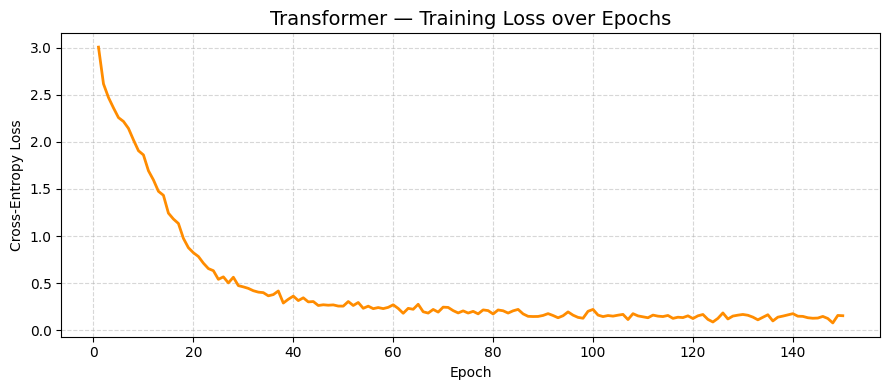

In [15]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS_TRANS + 1), trans_losses, color='darkorange', linewidth=2)
plt.title('Transformer — Training Loss over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 🎯 Sequence Generation — Transformer

In [16]:
def generate_transformer(model, seed, length=150, temperature=0.7):
    """
    Generate text using the Transformer model.

    Parameters
    ----------
    model       : trained TransformerModel
    seed        : seed string
    length      : number of characters to generate
    temperature : sampling temperature

    Returns
    -------
    str : seed + generated characters
    """
    model.eval()
    result  = seed

    context = [char2idx.get(c, 0) for c in seed]
    pad_len = max(0, SEQ_LEN - len(context))
    context = [0] * pad_len + context

    with torch.no_grad():
        for _ in range(length):
            inp    = torch.tensor([context[-SEQ_LEN:]], dtype=torch.long).to(device)
            logits = model(inp)[0] / temperature
            probs  = torch.softmax(logits, dim=0).cpu().numpy()
            idx    = int(np.random.choice(len(probs), p=probs))
            result += idx2char[idx]
            context.append(idx)

    return result


print('=' * 65)
print('  Transformer — Generated Sequences (temperature = 0.7)')
print('=' * 65)
for seed in seeds:
    generated = generate_transformer(transformer_model, seed, length=120, temperature=0.7)
    print(f'\n[Seed: "{seed}"]')
    print(generated)
    print('-' * 65)

  Transformer — Generated Sequences (temperature = 0.7)

[Seed: "deep learning"]
deep learningermom lsearning fe ffficincence
stenels aranimong morels cete tew ew ustrom stern pefom serks
om mompelllenerninlinerete
-----------------------------------------------------------------

[Seed: "neural networks"]
neural networks smumatle human brain stres
omptinte s auraition atuomizizitiong ata an aste aresente bexte w ere ste
s
urene saequene p
-----------------------------------------------------------------

[Seed: "sequence generation"]
sequence generation ustederoms inforomsentint areducint bots aurent aisaliman aint are steps
teps learning herm dfom ters learning tere sec
-----------------------------------------------------------------

[Seed: "artificial"]
artificialmpmoveles freauenefr sthem fromint itworore aueeste lencene are usequede modedernedediction ion botern s aea aenters ust
-----------------------------------------------------------------


---
## 📊 Step 5 — Model Comparison

### Loss Curves: LSTM vs Transformer

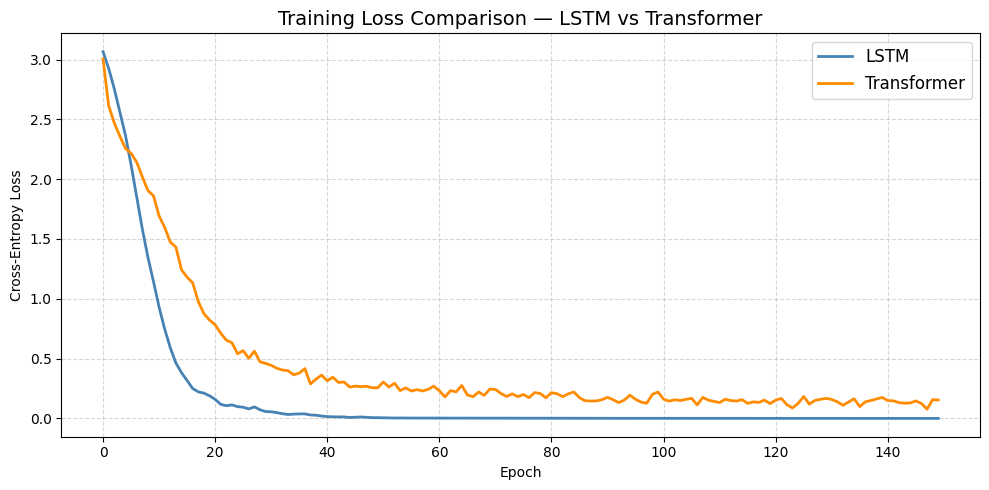

Final LSTM Loss        : 0.0004
Final Transformer Loss : 0.1540


In [17]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_losses,  label='LSTM',        color='steelblue',  linewidth=2)
plt.plot(trans_losses, label='Transformer', color='darkorange', linewidth=2)
plt.title('Training Loss Comparison — LSTM vs Transformer', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Final LSTM Loss        : {lstm_losses[-1]:.4f}')
print(f'Final Transformer Loss : {trans_losses[-1]:.4f}')

### Side-by-Side Generated Text Comparison

In [18]:
compare_seed = "language models"
GEN_LEN      = 130
TEMP         = 0.7

lstm_out  = generate_lstm(lstm_model, compare_seed, length=GEN_LEN, temperature=TEMP)
trans_out = generate_transformer(transformer_model, compare_seed, length=GEN_LEN, temperature=TEMP)

print('=' * 65)
print(f'Seed: "{compare_seed}" | length={GEN_LEN} | temperature={TEMP}')
print('=' * 65)
print('\n[LSTM Output]')
print(lstm_out)
print('\n[Transformer Output]')
print(trans_out)

Seed: "language models" | length=130 | temperature=0.7

[LSTM Output]
language models predict the next word in a sentence
sequence generation is used in chatbots and assistants
machine learning helps computers learn

[Transformer Output]
language modelseprese prede sext worer sinte
areninte
sentererengerels cus twore he setse hed cetsenempend ttue aromin lerm p
tes brefit searnint


---
## 📋 Summary & Key Insights

| Aspect | LSTM | Transformer |
|---|---|---|
| **Sequence Handling** | Sequential (time-step by time-step) | Parallel (all tokens at once) |
| **Memory Mechanism** | Cell state + gates | Multi-head self-attention |
| **Long-range Dependencies** | Good (but can still fade) | Excellent (direct token-to-token attention) |
| **Training Speed** | Slower (sequential) | Faster (parallelisable) |
| **Positional Info** | Built-in (recurrence) | Requires explicit positional encoding |
| **Typical Use** | Time series, speech, classic NLP | Modern NLP, LLMs, GPT, BERT |

### How Generation Works (both models)
1. **Encode** the seed text into integer indices.
2. **Pad** the context to `SEQ_LEN` characters.
3. **Forward pass** → get logits over the vocabulary.
4. **Temperature scaling** → divide logits by `temperature`.
5. **Softmax** → convert to probabilities.
6. **Sampling** → draw one character from the distribution.
7. **Append** the character, slide the context window, and repeat.